**Activity 02** - Data Mining Course
Student: Jansen Rodrigues de Avila
ID: 2102410001

Reference: https://colab.research.google.com/drive/1NMZaF4ahuUHBvgp7pGZIPngMUL3RMWeW?usp=sharing


*   **Dataset**

**Student Burnout Prediction Dataset** (https://www.kaggle.com/datasets/danieljhuang/student-burnout-prediction-dataset)

**Objetivo Geral**
Um dataset sintético mas realista de 2.000 estudantes do ensino médio, destinado para predizer burnouts baseado no dia-a-dia e variáveis de suporte.

**Colunas**
- **student_id**: Unique integer identifier for each student (1–2000).
- **grade**: Current high school grade level (9, 10, 11, or 12).
- **gender**: Self-reported gender. Categories: Female, Male, Nonbinary.
- **sleep_hours**: Average hours of sleep per night (range: 3.5–11.0).
- **sleep_quality**: Self-reported sleep quality on a 1–5 Likert scale (1 = very poor, 5 = excellent).
- **homework_hours**: Average hours spent on homework per day (range: 0.0–6.4).
- **tests_per_week**: Number of tests or quizzes in a typical week (range: 0–8).
- **extracurricular_hours**: Hours per week spent on extracurricular activities (range: 0.0–18.8).
- **num_activities**: Number of distinct extracurricular activities the student participates in (range: 0–7).
- **screen_time_hours**: Average recreational screen time per day in hours (range: 0.5–9.8). Contains missing values.
- **commute_minutes**: time in the journey between your home and your workplace or school
- **family_support**: score 1-5.
- **friend_support**: score 1-5.
- **teacher_support**: score 1-5.
- **self_rated_stress**: score 1-5.
- **burnout_score**: score 1-5.
- **high_burnout**: score 1 (high) and score 0 (low).

---

**Tools**
*   Python (Pandas)
*   Numpy

In [ ]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# use seaborn plotting defaults
import seaborn as sns; sns.set()

# import kmeans
from sklearn.cluster import KMeans

link = "https://raw.githubusercontent.com/janavila/data-science/refs/heads/main/datasets/student_burnout.csv"
dataframe = pd.read_csv(link, header=0)

dataframe.head()
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             2000 non-null   int64  
 1   grade                  2000 non-null   int64  
 2   gender                 2000 non-null   object 
 3   sleep_hours            2000 non-null   float64
 4   sleep_quality          2000 non-null   int64  
 5   homework_hours         2000 non-null   float64
 6   tests_per_week         2000 non-null   int64  
 7   extracurricular_hours  2000 non-null   float64
 8   num_activities         2000 non-null   int64  
 9   screen_time_hours      1956 non-null   float64
 10  commute_minutes        1970 non-null   float64
 11  family_support         2000 non-null   int64  
 12  friend_support         2000 non-null   int64  
 13  teacher_support        1952 non-null   float64
 14  self_rated_stress      2000 non-null   int64  
 15  burn

**Pré processamento**
- Limpeza realizada nos dados, removendo o *student_id* (sem nenhuma relevância para o projeto) e o *burnout_score* e *high_burnout* (evitando data leakage).
  - Serão usados para comparação posteriormente.


In [ ]:
colunas_alvo = dataframe[['high_burnout', 'burnout_score']].copy()

dataframe_final = dataframe.drop(
    columns=['student_id', 'burnout_score', 'high_burnout']
)

# One-Hot Encoding da variável 'gender'
#
# pd.get_dummies cria uma coluna binária (0/1) para cada categoria
# encontrada na coluna original. Isso evita impor uma ordem/distância (1, 2 e 3 respectivamente)
# artificial entre categorias que não têm ordem nenhuma (nominal).

dataframe_final = pd.get_dummies(
    dataframe_final,
    columns=['gender'],
    prefix='gender',
    drop_first=False
)

colunas_genero = ['gender_Female', 'gender_Male', 'gender_Nonbinary']
dataframe_final[colunas_genero] = dataframe_final[colunas_genero].astype(int) # Passa as colunas para inteiro em vez de ficar (True/False)


# Tratamento de valores nulos

# Checando se a ausência de valores se concentra em algum subgrupo
# (indício de MAR) ou parece espalhada (indício de MCAR)

for coluna in ['screen_time_hours', 'commute_minutes', 'teacher_support']:
    print(f"--- {coluna} ---")
    print(dataframe_final.groupby('grade')[coluna].apply(lambda x: x.isnull().sum()))
    print()

# Comparando média e mediana de cada coluna com nulos.
# Se média e mediana forem parecidas, a distribuição é ~simétrica
# (tanto faz usar uma ou outra). Se forem bem diferentes, há assimetria
# (cauda longa), e a mediana é a escolha mais segura.

for coluna in ['screen_time_hours', 'commute_minutes', 'teacher_support']:
    media = dataframe_final[coluna].mean()
    mediana = dataframe_final[coluna].median()
    print(f"{coluna}: média = {media:.2f} | mediana = {mediana:.2f}")

colunas_com_nulos = ['screen_time_hours', 'commute_minutes', 'teacher_support']

imputador = SimpleImputer(strategy='median') # Usa a mediana como estratégia para imputar valores as colunas que estão nulas, já que os valores estão quase simétricos (média e mediana)

dataframe_final[colunas_com_nulos] = imputador.fit_transform(
    dataframe_final[colunas_com_nulos]
)

# print(dataframe_final[colunas_com_nulos].isnull().sum()) # Para verificar se as colunas com nulos estão zeradas.
# Grade ficou como int64 com valores 9-12 — diferente de gender, essa é uma variável ordinal (9 < 10 < 11 < 12 tem ordem real e intervalos razoavelmente uniformes entre séries escolares),
# então mantê-la como número inteiro é uma decisão correta, sem precisar de one-hot.

dataframe_final.head()
dataframe_final.info()



--- screen_time_hours ---
grade
9      9
10    13
11     9
12    13
Name: screen_time_hours, dtype: int64

--- commute_minutes ---
grade
9     11
10     6
11     7
12     6
Name: commute_minutes, dtype: int64

--- teacher_support ---
grade
9     11
10     9
11    12
12    16
Name: teacher_support, dtype: int64

screen_time_hours: média = 4.14 | mediana = 4.10
commute_minutes: média = 23.47 | mediana = 23.00
teacher_support: média = 3.19 | mediana = 3.00
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   grade                  2000 non-null   int64  
 1   sleep_hours            2000 non-null   float64
 2   sleep_quality          2000 non-null   int64  
 3   homework_hours         2000 non-null   float64
 4   tests_per_week         2000 non-null   int64  
 5   extracurricular_hours  2000 non-null   float64
 6   num_activities

In [ ]:
# Normalização
# Observando as escalas das colunas, é possível observar quando variação de números
# commute_minutes: vai de ~5 até 77
# sleep_quality, family_support, friend_support, teacher_support, self_rated_stress: escalas Likert de 1 a 5
# gender_Female, gender_Male, gender_Nonbinary: só 0 ou 1
# extracurricular_hours: até 18,8

# k-means quanto o método hierárquico dependem de distância euclidiana (você viu isso na aula — a fórmula do k-means tem (p−ci)2(p - c_i)^2(p−ci​)2
# pré-requisito de todo o módulo de clustering,

dataframe_desc = dataframe_final.copy() # Apenas usado para copiar o dataframe antes de normalizar, para as estatísticas descritivas.

# Selecionando apenas as colunas contínuas/numéricas que precisam de
# normalização. As colunas de gênero (0/1) ficam de fora dessa lista (get_dummies) de propósito.
colunas_para_normalizar = [
    'grade', 'sleep_hours', 'sleep_quality', 'homework_hours',
    'tests_per_week', 'extracurricular_hours', 'num_activities',
    'screen_time_hours', 'commute_minutes', 'family_support',
    'friend_support', 'teacher_support', 'self_rated_stress'
]

scaler = StandardScaler() # não tem limite fixo, utilizando uma fórmula para padronização no transform.

# fit_transform faz duas coisas em uma chamada:
#   fit()       → calcula a média e o desvio padrão de CADA coluna
#                 listada, a partir dos dados que você passou.
#   transform() → aplica a fórmula (x - média) / desvio_padrão
#                 em cada valor, usando os parâmetros aprendidos no fit.
dataframe_final[colunas_para_normalizar] = scaler.fit_transform(
    dataframe_final[colunas_para_normalizar]
)

dataframe_final.describe()

,grade,sleep_hours,sleep_quality,homework_hours,tests_per_week,extracurricular_hours,num_activities,screen_time_hours,commute_minutes,family_support,friend_support,teacher_support,self_rated_stress,gender_Female,gender_Male,gender_Nonbinary
count,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2000.000000,2000.000000,2000.00000
mean,5.240253e-16,-3.339551e-16,2.180478e-16,-4.618528e-17,-8.881784e-17,-3.836931e-16,-7.815970e-17,-1.332268e-16,4.440892e-17,7.105427e-18,-1.101341e-16,-1.350031e-16,9.947598e-17,0.495500,0.482500,0.02200
std,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,0.500105,0.499819,0.14672
min,-1.272850e+00,-3.841122e+00,-2.990684e+00,-2.323941e+00,-1.345044e+00,-1.655328e+00,-1.428692e+00,-2.166279e+00,-1.522598e+00,-2.557871e+00,-2.952051e+00,-2.188376e+00,-1.794366e+00,0.000000,0.000000,0.00000
25%,-1.272850e+00,-6.625913e-01,-6.835025e-01,-6.912593e-01,-5.942521e-01,-7.320816e-01,-7.539851e-01,-6.772637e-01,-8.131094e-01,-5.394287e-01,-7.641309e-01,-1.880323e-01,-6.945401e-01,0.000000,0.000000,0.00000
50%,-3.880048e-01,4.374895e-02,4.700882e-01,3.437702e-02,1.565402e-01,-4.624145e-02,-7.927808e-02,-2.209699e-02,-3.267195e-02,4.697924e-01,3.298289e-01,-1.880323e-01,4.052859e-01,0.000000,0.000000,0.00000
75%,4.968408e-01,6.617966e-01,4.700882e-01,6.693088e-01,9.073325e-01,6.923556e-01,5.954290e-01,6.330697e-01,6.768166e-01,4.697924e-01,3.298289e-01,8.121397e-01,4.052859e-01,1.000000,1.000000,0.00000
max,1.381687e+00,2.780817e+00,1.623679e+00,3.481150e+00,4.661294e+00,3.303824e+00,3.294257e+00,3.372858e+00,3.798566e+00,1.479014e+00,1.423789e+00,1.812312e+00,2.604938e+00,1.000000,1.000000,1.00000


**Estatísticas Descritivas**

/tmp/ipykernel_2325/2461996492.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=dataframe_desc['grade'].astype(int), palette='viridis', ax=axes[0,0])
/tmp/ipykernel_2325/2461996492.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=dataframe_desc['num_activities'].astype(int), palette='viridis', ax=axes[1,1])


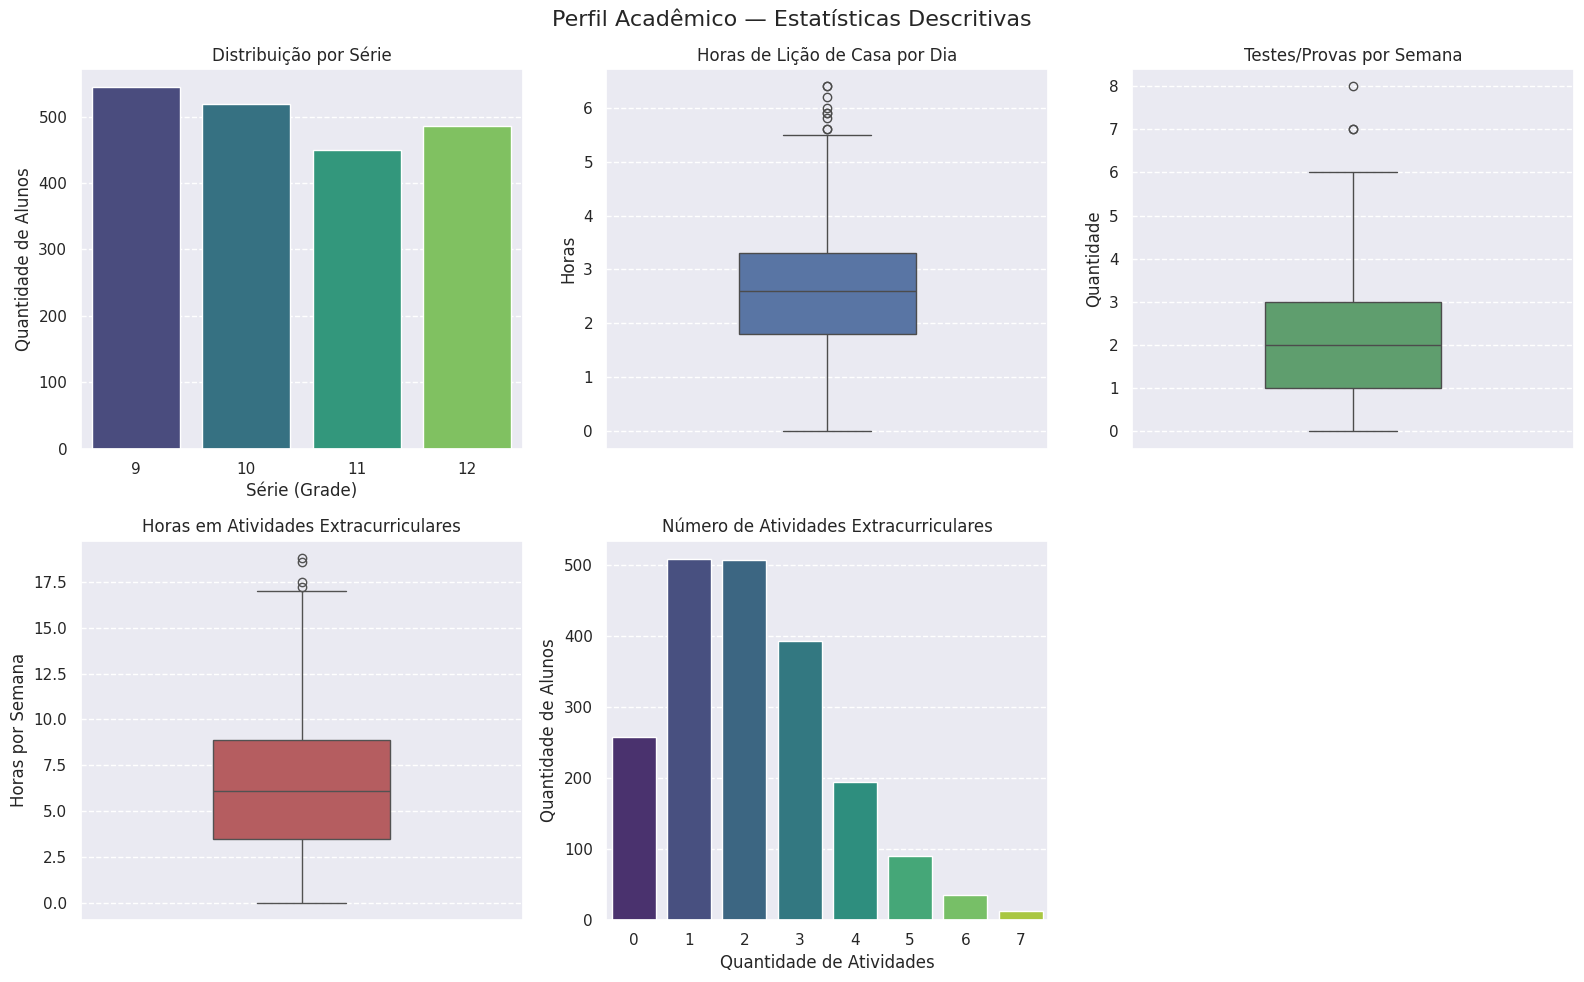

In [ ]:
# Perfis Acadêmicos

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# grade: só 4 valores possíveis → countplot
sns.countplot(x=dataframe_desc['grade'].astype(int), palette='viridis', ax=axes[0,0])
axes[0,0].set_title('Distribuição por Série')
axes[0,0].set_xlabel('Série (Grade)')
axes[0,0].set_ylabel('Quantidade de Alunos')

# homework_hours: contínua → boxplot
sns.boxplot(y=dataframe_desc['homework_hours'], color='#4C72B0', ax=axes[0,1], width=0.4)
axes[0,1].set_title('Horas de Lição de Casa por Dia')
axes[0,1].set_ylabel('Horas')

# tests_per_week: discreta, faixa moderada → boxplot
sns.boxplot(y=dataframe_desc['tests_per_week'], color='#55A868', ax=axes[0,2], width=0.4)
axes[0,2].set_title('Testes/Provas por Semana')
axes[0,2].set_ylabel('Quantidade')

# extracurricular_hours: contínua → boxplot
sns.boxplot(y=dataframe_desc['extracurricular_hours'], color='#C44E52', ax=axes[1,0], width=0.4)
axes[1,0].set_title('Horas em Atividades Extracurriculares')
axes[1,0].set_ylabel('Horas por Semana')

# num_activities: discreta, poucas categorias → countplot
sns.countplot(x=dataframe_desc['num_activities'].astype(int), palette='viridis', ax=axes[1,1])
axes[1,1].set_title('Número de Atividades Extracurriculares')
axes[1,1].set_xlabel('Quantidade de Atividades')
axes[1,1].set_ylabel('Quantidade de Alunos')

# painel vazio (5 variáveis em grade 2x3) — desligamos o eixo
axes[1,2].axis('off')

for ax in axes.flat:
    if ax.has_data():
        ax.yaxis.grid(True, linestyle='--')
        ax.set_axisbelow(True)

plt.suptitle('Perfil Acadêmico — Estatísticas Descritivas', fontsize=16)
plt.tight_layout()
plt.savefig('grafico_perfil_academico.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_2325/2664640220.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=dataframe_desc[col].astype(int), palette='mako', ax=ax)
/tmp/ipykernel_2325/2664640220.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=dataframe_desc[col].astype(int), palette='mako', ax=ax)
/tmp/ipykernel_2325/2664640220.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=dataframe_desc[col].astype(int), palette='mako', ax=ax)
/tmp/ipykernel_2325/2664640220.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and 

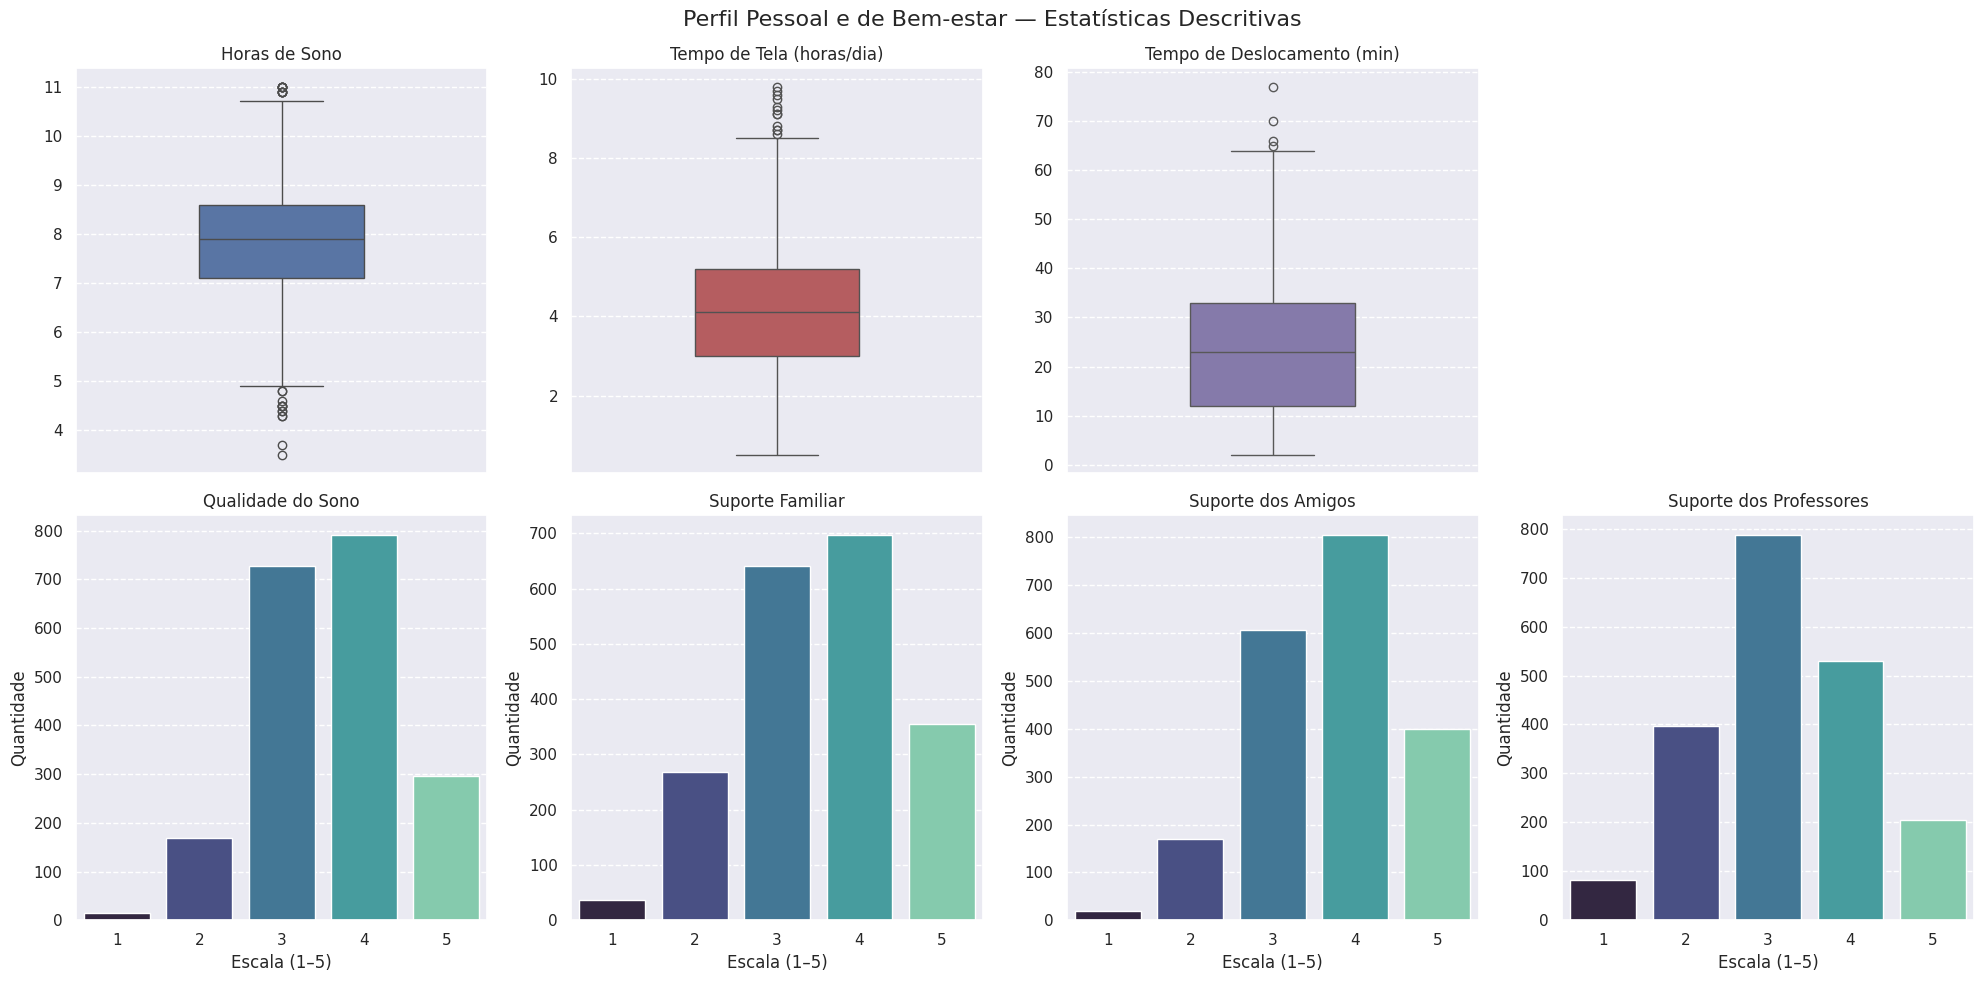

In [ ]:
# Perfil de Bem-Estar/Pessoal

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Contínuas → boxplot
continuas = [
    ('sleep_hours', 'Horas de Sono', '#4C72B0'),
    ('screen_time_hours', 'Tempo de Tela (horas/dia)', '#C44E52'),
    ('commute_minutes', 'Tempo de Deslocamento (min)', '#8172B2'),
]
for (col, titulo, cor), ax in zip(continuas, axes[0, :3]):
    sns.boxplot(y=dataframe_desc[col], color=cor, ax=ax, width=0.4)
    ax.set_title(titulo)
    ax.set_ylabel('')

axes[0, 3].axis('off')  # slot vazio na primeira linha

# Likert 1-5 → countplot
likert = [
    ('sleep_quality', 'Qualidade do Sono'),
    ('family_support', 'Suporte Familiar'),
    ('friend_support', 'Suporte dos Amigos'),
    ('teacher_support', 'Suporte dos Professores'),
]
for (col, titulo), ax in zip(likert, axes[1, :]):
    sns.countplot(x=dataframe_desc[col].astype(int), palette='mako', ax=ax)
    ax.set_title(titulo)
    ax.set_xlabel('Escala (1–5)')
    ax.set_ylabel('Quantidade')

for ax in axes.flat:
    if ax.has_data():
        ax.yaxis.grid(True, linestyle='--')
        ax.set_axisbelow(True)

plt.suptitle('Perfil Pessoal e de Bem-estar — Estatísticas Descritivas', fontsize=16)
plt.tight_layout()
plt.savefig('grafico_perfil_pessoal.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_2325/238341208.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=dataframe['gender'], palette='Set2', ax=axes[0],
/tmp/ipykernel_2325/238341208.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=dataframe_desc['self_rated_stress'].astype(int), palette='rocket', ax=axes[1])
/tmp/ipykernel_2325/238341208.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=colunas_alvo['high_burnout'], palette='flare', ax=axes[2])
/tmp/ipykernel_2325/238341208.py:23: UserWarning: set_ticklabels() should only be used with a fixed 

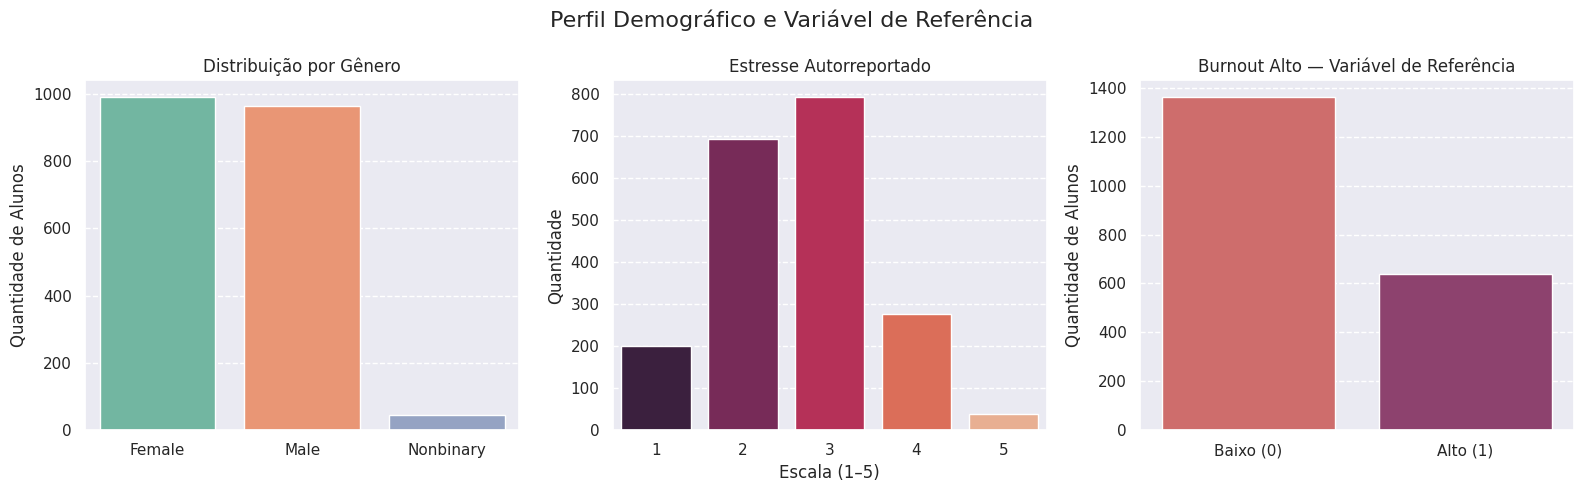

In [ ]:
# Variáveis nominais (gênero) e referência

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gênero: nominal, poucas categorias → countplot
# Usamos o dataframe ORIGINAL aqui, porque 'gender' já foi convertida
# em colunas dummy no dataframe_final/dataframe_desc — o texto original
# só existe no 'dataframe' bruto carregado na Etapa 1.
sns.countplot(x=dataframe['gender'], palette='Set2', ax=axes[0],
              order=['Female', 'Male', 'Nonbinary'])
axes[0].set_title('Distribuição por Gênero')
axes[0].set_xlabel('')
axes[0].set_ylabel('Quantidade de Alunos')

# self_rated_stress: Likert, isolado por relevância
sns.countplot(x=dataframe_desc['self_rated_stress'].astype(int), palette='rocket', ax=axes[1])
axes[1].set_title('Estresse Autorreportado')
axes[1].set_xlabel('Escala (1–5)')
axes[1].set_ylabel('Quantidade')

# high_burnout: variável de referência (NÃO usada no clustering)
sns.countplot(x=colunas_alvo['high_burnout'], palette='flare', ax=axes[2])
axes[2].set_xticklabels(['Baixo (0)', 'Alto (1)'])
axes[2].set_title('Burnout Alto — Variável de Referência')
axes[2].set_xlabel('')
axes[2].set_ylabel('Quantidade de Alunos')

for ax in axes:
    ax.yaxis.grid(True, linestyle='--')
    ax.set_axisbelow(True)

plt.suptitle('Perfil Demográfico e Variável de Referência', fontsize=16)
plt.tight_layout()
plt.savefig('grafico_genero_burnout_referencia.png', dpi=300, bbox_inches='tight')
plt.show()

**Clustering**
- Algoritmos usados:
  - **K-Means**
  - **Hierárquico**

**K-Means**

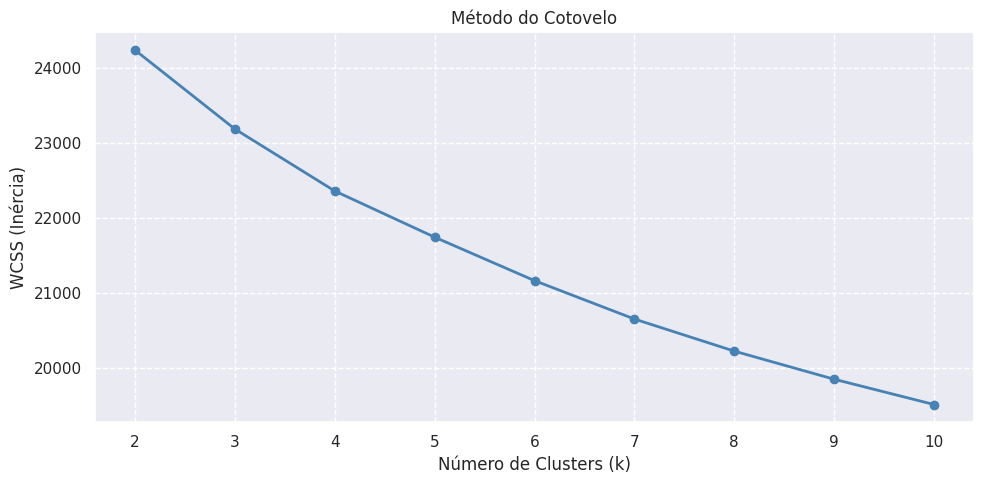

In [ ]:
# K-Means
# Quais colunas entram no clustering: dataframe_final (sem id, burnout_score e high_burnout)


# Descobrindo o K ideal.

distorcoes = []  # vai guardar a inércia (WCSS) de cada valor de k testado
#lista vazia que vai acumular um número por iteração do loop: a inércia do modelo treinado naquele k específico.

valores_k = range(2, 11)  # de 2 a 10 clusters

for k in valores_k: # Faz a iteração para cada número de clusters testados.
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++', # espalha os centróides iniciais de forma que fiquem bem distantes uns dos outros logo de cara, reduzindo a chance de começar mal.
        n_init=10, # diz para o sklearn rodar o algoritmo inteiro 10 vezes, cada vez com uma inicialização ligeiramente diferente, e no final ficar só com a melhor rodada (a que tiver menor inércia)
        random_state=42
    )
    kmeans.fit(dataframe_final)
    distorcoes.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(valores_k, distorcoes, marker='o', color='steelblue', linewidth=2)
plt.xlabel('Número de Clusters (k)')
plt.ylabel('WCSS (Inércia)')
plt.title('Método do Cotovelo')
plt.grid(True, linestyle='--')
plt.xticks(valores_k)
plt.tight_layout()
plt.savefig('grafico_metodo_cotovelo.png', dpi=300, bbox_inches='tight')
plt.show()

# A curva estando descrescente de forma muito suave, a desaceleração é gradual demais para ter um ponto óbvio — é uma curva convexa suave, sem quebra abrupta.

#calcular numericamente a taxa de queda entre cada k e o seguinte, e ver onde ela para de "valer a pena"

**Silhueta para análise de K**

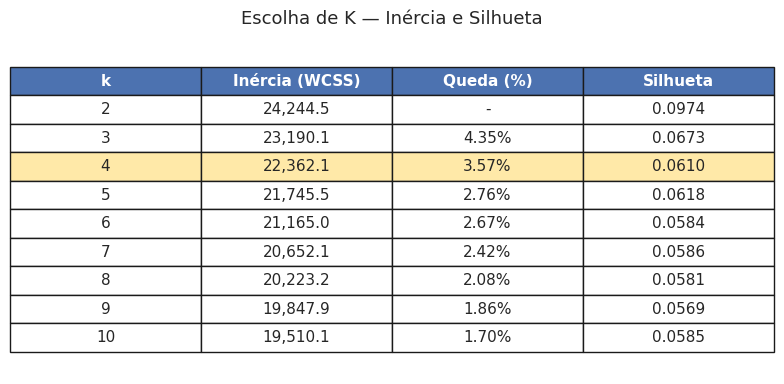

In [ ]:
silhuetas = []

for k in valores_k:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=42
    )
    labels = kmeans.fit_predict(dataframe_final)
    score = silhouette_score(dataframe_final, labels, metric='euclidean')
    silhuetas.append(score)

tabela_k = pd.DataFrame({
    'k': list(valores_k),
    'Inércia (WCSS)': distorcoes,
    'Silhueta': silhuetas
})

# Queda percentual da inércia entre um k e o anterior
tabela_k['Queda (%)'] = tabela_k['Inércia (WCSS)'].pct_change() * -100
tabela_k['Queda (%)'] = tabela_k['Queda (%)'].round(2)
tabela_k['Inércia (WCSS)'] = tabela_k['Inércia (WCSS)'].round(1)
tabela_k['Silhueta'] = tabela_k['Silhueta'].round(4)

# Reordenando as colunas na sequência que queremos exibir
tabela_k = tabela_k[['k', 'Inércia (WCSS)', 'Queda (%)', 'Silhueta']]

fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')  # não queremos eixos X/Y, só a tabela

# Formatando os valores como texto, com o estilo visual que queremos
tabela_str = tabela_k.copy()
tabela_str['Queda (%)'] = tabela_str['Queda (%)'].apply(
    lambda x: '-' if pd.isna(x) else f'{x:.2f}%'
)
tabela_str['Inércia (WCSS)'] = tabela_str['Inércia (WCSS)'].apply(lambda x: f'{x:,.1f}')
tabela_str['Silhueta'] = tabela_str['Silhueta'].apply(lambda x: f'{x:.4f}')

tabela = ax.table(
    cellText=tabela_str.values,
    colLabels=tabela_str.columns,
    cellLoc='center',
    loc='center'
)
tabela.auto_set_font_size(False)
tabela.set_fontsize(11)
tabela.scale(1, 1.6)

# Destacando a linha do k escolhido (aqui, k=4)
k_escolhido = 4
idx_destaque = tabela_k[tabela_k['k'] == k_escolhido].index[0] + 1
for col in range(len(tabela_k.columns)):
    tabela[(idx_destaque, col)].set_facecolor('#FFE9A8')

# Cabeçalho estilizado
for col in range(len(tabela_k.columns)):
    tabela[(0, col)].set_facecolor('#4C72B0')
    tabela[(0, col)].set_text_props(color='white', fontweight='bold')

plt.title('Escolha de K — Inércia e Silhueta', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('tabela_escolha_k.png', dpi=300, bbox_inches='tight')
plt.show()

# **Justificativa da Escolha de K**

# O método do cotovelo, aplicado de k=2 a k=10, não apresentou uma dobra abrupta na curva de inércia (WCSS) — a queda percentual entre valores consecutivos de k diminui de forma gradual
# Optou-se por k=4, equilibrando: (1) uma queda percentual de inércia ainda relevante (3,57%) antes da curva estabilizar, e (2) uma silhueta comparável à dos valores de k maiores, evitando a complexidade de
# interpretar um número excessivo de grupos sem ganho real de separação.

In [ ]:
# Análise Final.

modelo_final = KMeans(
    n_clusters=4,
    init='k-means++',
    n_init=10,
    random_state=42
)

dataframe_desc['cluster'] = modelo_final.fit_predict(dataframe_final)

perfis = dataframe_desc.groupby('cluster')[colunas_para_normalizar].mean().round(2) # divide o DataFrame em 4 sub-tabelas, uma para cada valor da coluna cluster (0, 1, 2, 3)
# no colunas_para_normalizar seleciona só as colunas numéricas que fazem sentido "tirar média" (a mesma lista cols_norm que usamos na normalização)
# .mean(): calcula a média de cada coluna, dentro de cada grupo já separado pelo groupby. É essa comparação de médias entre grupos que revela o "personagem" de cada cluster.
print(perfis.T)


# Comparação externa com o High_Burnout.

# Cria uma tabela de contingência — conta quantos alunos caem em cada combinação de (cluster, high_burnout).
# O parâmetro normalize='index' transforma essas contagens em proporções dentro de cada linha (cada cluster) — ou seja, em vez de "cluster 1 tem 340 alunos com burnout alto"
# Você vê "65,5% dos alunos do cluster 1 têm burnout alto". Isso é o que faz a comparação ser interpretável cluster a cluster.

comparacao = pd.crosstab(
    dataframe_desc['cluster'],
    colunas_alvo['high_burnout'],
    normalize='index'
)





cluster                    0      1      2      3
grade                   9.58  11.12  11.23   9.97
sleep_hours             7.79   6.80   8.06   8.73
sleep_quality           3.44   3.05   3.81   4.07
homework_hours          1.81   3.04   3.35   2.19
tests_per_week          1.34   1.76   2.90   1.38
extracurricular_hours   6.27   6.36   6.01   6.41
num_activities          2.50   1.87   2.38   1.80
screen_time_hours       4.50   5.30   3.54   3.18
commute_minutes        26.81  21.84  25.17  20.64
family_support          3.10   3.71   3.35   3.90
friend_support          3.66   3.47   3.94   3.77
teacher_support         3.46   2.97   3.31   3.05
self_rated_stress       2.50   3.18   3.08   1.90


**Explicação Técnica:**

O algoritmo precisa calcular distâncias, então tem que rodar sobre os dados normalizados (dataframe_final) — é isso que garante que commute_minutes não domine a distância só por ter uma escala maior. Mas o resultado (a qual grupo cada aluno pertence) é só um número de 0 a 3. Tem os valores em escala original e legível (horas de sono de verdade, minutos de deslocamento reais). Assim, quando formos interpretar os clusters daqui a pouco, veremos "o cluster 3 dorme em média 8,7 horas" em vez de "o cluster 3 tem z-score médio de 0,68".

- Os grupos ficaram **razoavelmente equilibrados** (entre 426 e 554 alunos, de um total de 2000)

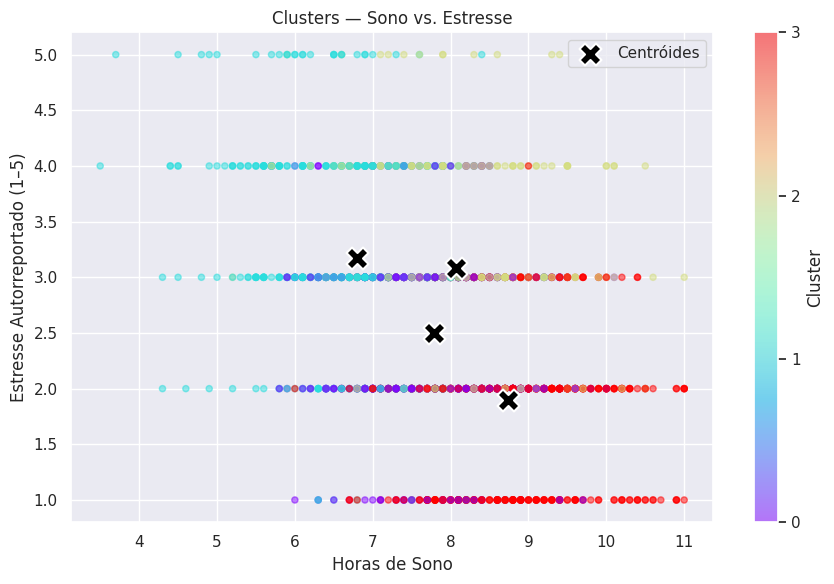

In [ ]:
plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    dataframe_desc['sleep_hours'],
    dataframe_desc['self_rated_stress'],
    c=dataframe_desc['cluster'],
    cmap='rainbow',
    s=20,
    alpha=0.5
)

# Centróides: a média de CADA cluster, só nessas 2 variáveis
centroides_2d = dataframe_desc.groupby('cluster')[['sleep_hours', 'self_rated_stress']].mean()

plt.scatter(
    centroides_2d['sleep_hours'],
    centroides_2d['self_rated_stress'],
    s=250, c='black', marker='X', label='Centróides', edgecolors='white', linewidths=1.5
)

plt.xlabel('Horas de Sono')
plt.ylabel('Estresse Autorreportado (1–5)')
plt.title('Clusters — Sono vs. Estresse')
plt.colorbar(scatter, label='Cluster', ticks=[0,1,2,3])
plt.legend()
plt.tight_layout()
plt.savefig('grafico_clusters_sono_estresse.png', dpi=300, bbox_inches='tight')
plt.show()

**Gráfico 1**: dispersão com clusters coloridos + centróides

**sleep_hours** e **self_rated_stress**, porque foram as que mais diferenciaram os clusters na tabela de perfis (cluster 1 com sono baixo estresse alto, cluster 3 com sono alto/estresse baixo).

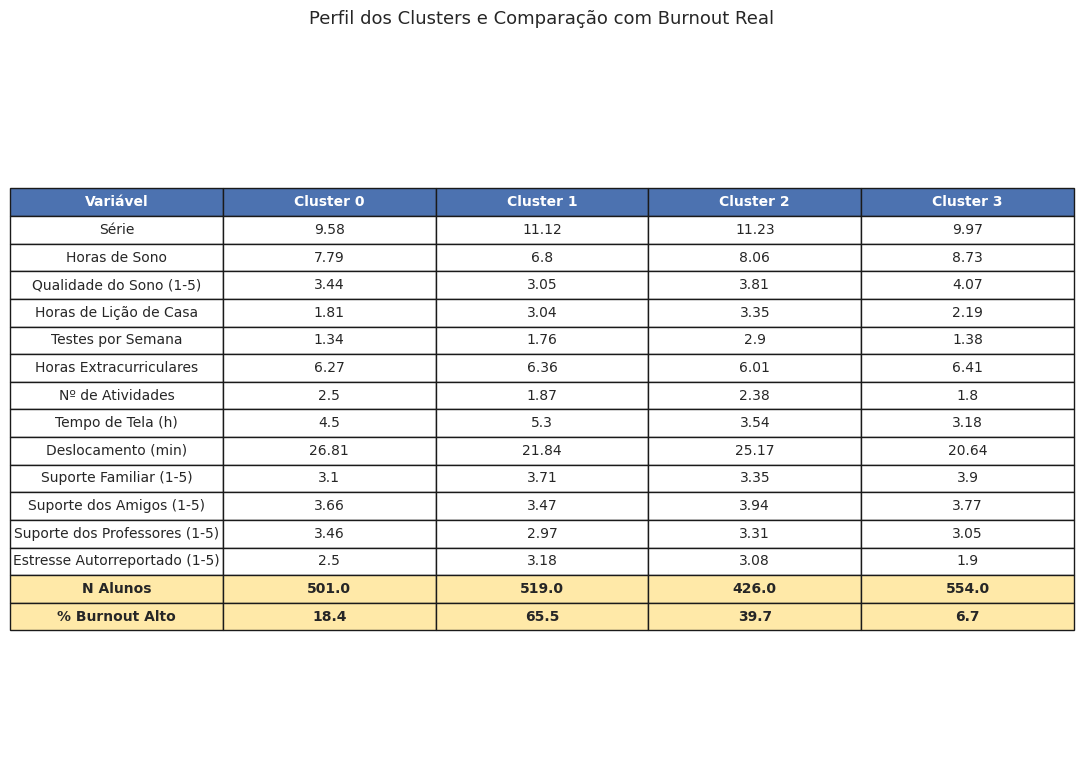

In [ ]:
# 1. Perfil médio de cada variável, por cluster (já tínhamos isso)
perfis = dataframe_desc.groupby('cluster')[colunas_para_normalizar].mean().round(2)

# 2. Tamanho de cada cluster
tamanhos = dataframe_desc['cluster'].value_counts().sort_index()

# 3. % de burnout alto por cluster (o crosstab de antes, normalizado por linha)
comparacao = pd.crosstab(
    dataframe_desc['cluster'], colunas_alvo['high_burnout'], normalize='index'
) * 100
pct_burnout_alto = comparacao[1].round(1)

# 4. Transpõe o perfil (variáveis viram linhas, clusters viram colunas)
#    e adiciona as duas métricas extras como linhas no final
tabela_consolidada = perfis.T
tabela_consolidada.loc['N Alunos'] = tamanhos
tabela_consolidada.loc['% Burnout Alto'] = pct_burnout_alto

rotulos_variaveis = {
    'grade': 'Série',
    'sleep_hours': 'Horas de Sono',
    'sleep_quality': 'Qualidade do Sono (1-5)',
    'homework_hours': 'Horas de Lição de Casa',
    'tests_per_week': 'Testes por Semana',
    'extracurricular_hours': 'Horas Extracurriculares',
    'num_activities': 'Nº de Atividades',
    'screen_time_hours': 'Tempo de Tela (h)',
    'commute_minutes': 'Deslocamento (min)',
    'family_support': 'Suporte Familiar (1-5)',
    'friend_support': 'Suporte dos Amigos (1-5)',
    'teacher_support': 'Suporte dos Professores (1-5)',
    'self_rated_stress': 'Estresse Autorreportado (1-5)'
}

tabela_consolidada = tabela_consolidada.rename(index=rotulos_variaveis)

fig, ax = plt.subplots(figsize=(11, 8))
ax.axis('off')

# Formatando os números como texto antes de desenhar
tabela_str = tabela_consolidada.reset_index()
tabela_str.columns = ['Variável', 'Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

tabela_render = ax.table(
    cellText=tabela_str.values,
    colLabels=tabela_str.columns,
    cellLoc='center',
    loc='center'
)
tabela_render.auto_set_font_size(False)
tabela_render.set_fontsize(10)
tabela_render.scale(1, 1.4)

n_linhas = len(tabela_str)

# Cabeçalho estilizado
for col in range(len(tabela_str.columns)):
    tabela_render[(0, col)].set_facecolor('#4C72B0')
    tabela_render[(0, col)].set_text_props(color='white', fontweight='bold')

# Destacando as duas últimas linhas (N Alunos e % Burnout Alto)
for linha in [n_linhas - 1, n_linhas]:  # +1 por causa do cabeçalho na linha 0
    for col in range(len(tabela_str.columns)):
        tabela_render[(linha, col)].set_facecolor('#FFE9A8')
        tabela_render[(linha, col)].set_text_props(fontweight='bold')

plt.title('Perfil dos Clusters e Comparação com Burnout Real', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('tabela_perfil_clusters_consolidada.png', dpi=300, bbox_inches='tight')
plt.show()

**Cluster 0 (501 alunos)**: alunos mais novos (série 9,58), com perfil intermediário em quase tudo, mas com o maior tempo de deslocamento (26,81 min) e suporte familiar mais baixo (3,10) — um perfil mais neutro, sem um traço tão extremo quanto os outros três.

**Cluster 1 (519 alunos)**: o perfil de maior risco — é quem menos dorme (6,80h), quem mais consome tela recreativa (5,30h), e tem o maior estresse autorreportado (3,18). Também estuda bastante (homework_hours alto), o que sugere uma combinação de carga acadêmica com privação de sono.

**Cluster 2 (426 alunos)**: alunos mais velhos (série 11,23), com a maior carga de provas (quase 3 testes por semana) e mais horas de estudo — um perfil de "pressão acadêmica alta", mas com sono relativamente preservado (8,06h).

**Cluster 3 (554 alunos)**: o perfil mais saudável — melhor sono (8,73h), menor tempo de tela (3,18h), maior suporte familiar (3,90) e o menor estresse (1,90) de todos os grupos.

**Método Hierárquico**

Começa tratando cada um dos 2000 alunos como seu próprio cluster, e então,repetidamente, funde os dois clusters mais próximos num só — até sobrar apenas um cluster gigante com todo mundo. Isso é feito 1999 vezes (sempre N−1 fusões para N pontos, porque cada fusão reduz a contagem de clusters em 1, até chegar a 1).

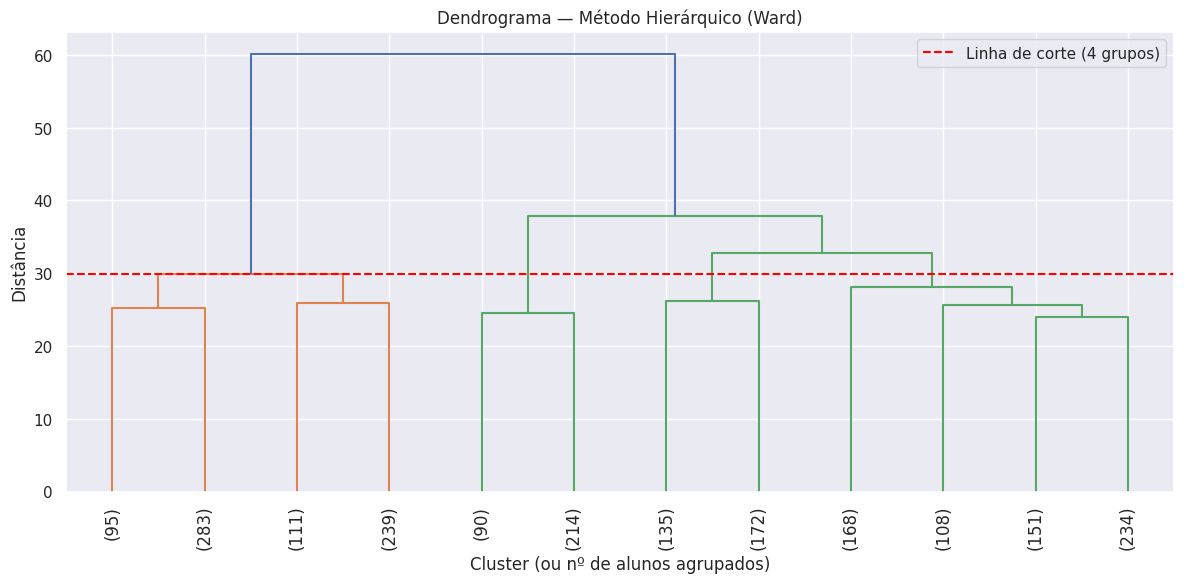

In [ ]:
Z = linkage(dataframe_final, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(
    Z,
    truncate_mode='lastp',
    p=12,
    leaf_rotation=90,
    show_leaf_counts=True
)
plt.title('Dendrograma — Método Hierárquico (Ward)')
plt.xlabel('Cluster (ou nº de alunos agrupados)')
plt.ylabel('Distância')
plt.axhline(y=Z[-4, 2], color='red', linestyle='--', label='Linha de corte (4 grupos)')
plt.legend()
plt.tight_layout()
plt.savefig('grafico_dendrograma.png', dpi=300, bbox_inches='tight')
plt.show()

dataframe_desc['cluster_hier'] = fcluster(Z, t=4, criterion='maxclust')


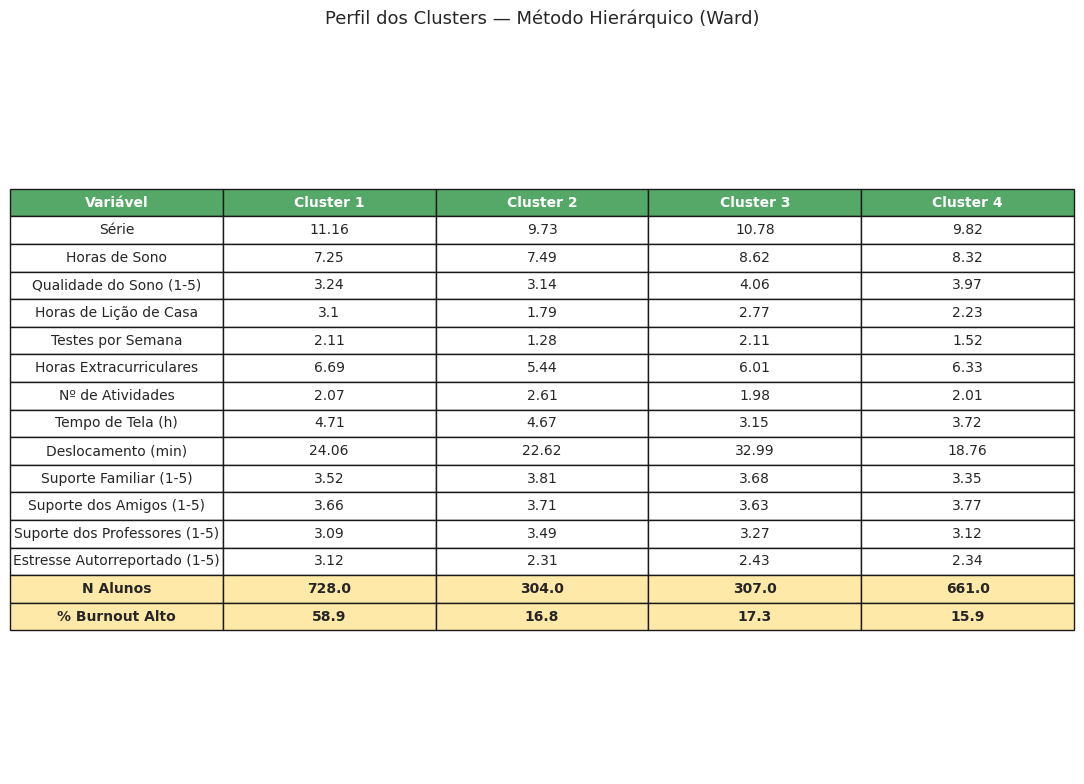

In [ ]:
# 1. Perfil médio de cada variável, dentro de cada cluster hierárquico
perfis_hier = dataframe_desc.groupby('cluster_hier')[colunas_para_normalizar].mean().round(2)

# 2. Tamanho de cada cluster
tamanhos_hier = dataframe_desc['cluster_hier'].value_counts().sort_index()

# 3. % de burnout alto por cluster (mesma lógica do crosstab de antes)
comparacao_hier = pd.crosstab(
    dataframe_desc['cluster_hier'], colunas_alvo['high_burnout'], normalize='index'
) * 100
pct_burnout_hier = comparacao_hier[1].round(1)

# 4. Consolidando: variáveis em linha, clusters em coluna
tabela_hier = perfis_hier.T
tabela_hier.loc['N Alunos'] = tamanhos_hier
tabela_hier.loc['% Burnout Alto'] = pct_burnout_hier
tabela_hier = tabela_hier.rename(index=rotulos_variaveis)

fig, ax = plt.subplots(figsize=(11, 8))
ax.axis('off')

tabela_str = tabela_hier.reset_index()
tabela_str.columns = ['Variável', 'Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4']

tabela_render = ax.table(
    cellText=tabela_str.values,
    colLabels=tabela_str.columns,
    cellLoc='center',
    loc='center'
)
tabela_render.auto_set_font_size(False)
tabela_render.set_fontsize(10)
tabela_render.scale(1, 1.4)

n_linhas = len(tabela_str)

for col in range(len(tabela_str.columns)):
    tabela_render[(0, col)].set_facecolor('#55A868')  # verde, para diferenciar visualmente do k-means (azul)
    tabela_render[(0, col)].set_text_props(color='white', fontweight='bold')

for linha in [n_linhas - 1, n_linhas]:
    for col in range(len(tabela_str.columns)):
        tabela_render[(linha, col)].set_facecolor('#FFE9A8')
        tabela_render[(linha, col)].set_text_props(fontweight='bold')

plt.title('Perfil dos Clusters — Método Hierárquico (Ward)', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('tabela_perfil_hierarquico.png', dpi=300, bbox_inches='tight')
plt.show()



O **cluster 1** do k-means tem 405 dos seus 519 alunos concentrados no cluster 1 do hierárquico — uma concordância forte, os dois métodos "concordam" bastante sobre quem pertence a esse grupo. Já o cluster 0 do k-means está bem espalhado entre os 4 clusters hierárquicos (66, 191, 46, 198) — não há uma correspondência clara, os dois métodos discordam bastante sobre esse grupo específico.


O método hierárquico formou um cluster grande e claramente de alto risco (Cluster 1, com 728 alunos — mais de um terço da base — concentrando o maior estresse, mais horas de estudo, e uma taxa de burnout de quase 59%), enquanto os outros três clusters ficam bem parecidos entre si em taxa de burnout (16-17%), sem tanta diferenciação adicional entre eles.

Diferente do que o k-means mostrou. Aqui, o Ward parece ter feito uma divisão mais "binária" — um grupo claramente de risco versus o resto, sem tanta gradação intermediária. Essa é uma observação genuinamente interessante para comparar os dois métodos no seu relatório: os dois concordam que existe um grupo de alto risco identificável, mas discordam sobre como o "resto" da população se subdivide.

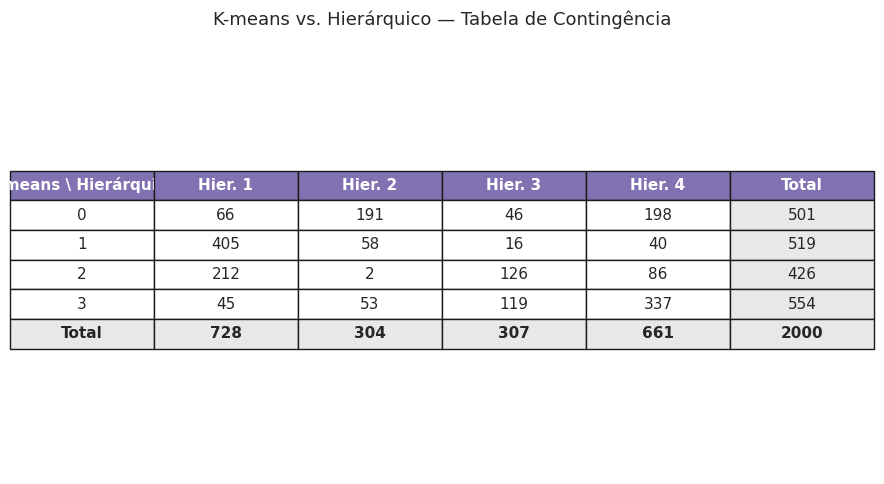

In [ ]:
comparacao_metodos = pd.crosstab(
    dataframe_desc['cluster'],
    dataframe_desc['cluster_hier'],
    margins=True,
    margins_name='Total'
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.axis('off')

tabela_str = comparacao_metodos.reset_index()
tabela_str.columns = ['K-means \\ Hierárquico', 'Hier. 1', 'Hier. 2', 'Hier. 3', 'Hier. 4', 'Total']

tabela_render = ax.table(
    cellText=tabela_str.values,
    colLabels=tabela_str.columns,
    cellLoc='center',
    loc='center'
)
tabela_render.auto_set_font_size(False)
tabela_render.set_fontsize(11)
tabela_render.scale(1, 1.6)

n_linhas, n_cols = tabela_str.shape

# Cabeçalho
for col in range(n_cols):
    tabela_render[(0, col)].set_facecolor('#8172B2')
    tabela_render[(0, col)].set_text_props(color='white', fontweight='bold')

# Linha e coluna de Total em cinza claro, para diferenciar dos dados "de verdade"
for col in range(n_cols):
    tabela_render[(n_linhas, col)].set_facecolor('#E8E8E8')
    tabela_render[(n_linhas, col)].set_text_props(fontweight='bold')
for linha in range(1, n_linhas + 1):
    tabela_render[(linha, n_cols - 1)].set_facecolor('#E8E8E8')

plt.title('K-means vs. Hierárquico — Tabela de Contingência', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('tabela_comparacao_kmeans_hierarquico.png', dpi=300, bbox_inches='tight')
plt.show()


**Tabela de Contingência**
- Dos alunos que o k-means colocou no grupo X, para onde eles foram no método hierárquico?

Cada célula é uma contagem dupla
- Por exemplo, a célula na linha 1 (k-means) e coluna 1 (hierárquico) tem o valor 405: isso significa que 405 alunos foram classificados como "cluster 1" pelos dois métodos ao mesmo tempo. Já a célula na linha 0, coluna 2 (valor 191) significa que 191 alunos que o k-means colocou no grupo 0 acabaram no grupo 2 do hierárquico.

O cluster 1 do k-means é, disparado, o mais consistente entre os dois métodos: 78% dos seus alunos foram parar no mesmo grupo (cluster 1) no hierárquico — os dois algoritmos "concordam" fortemente aqui. Já o cluster 0 é o mais inconsistente: só 39,5% ficaram concentrados numa única coluna, o resto se espalhou quase igualmente pelas outras três.